# Phase 5: Random Forest Filter for Trade Quality
This notebook trains a classifier to accept/reject statistical trade entries.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

DATA_DIR = Path('../data')
OUT_DIR = Path('../outputs')

prices = pd.read_csv(DATA_DIR / 'nifty_prices_clean.csv', index_col=0, parse_dates=True)
pairs = pd.read_csv(DATA_DIR / 'selected_pairs.csv')
pair = pairs.iloc[0]
a, b = pair['stock_a'], pair['stock_b']
beta_static = float(pair['beta_a_on_b'])

print(f'Model pair: {a} vs {b}')

Model pair: HEROMOTOCO.NS vs EICHERMOT.NS


In [2]:
# Rebuild spread and features
beta_roll = prices[a].rolling(252).cov(prices[b]) / prices[b].rolling(252).var()
beta = beta_roll.fillna(beta_static)
spread = prices[a] - beta * prices[b]
z = (spread - spread.rolling(30).mean()) / spread.rolling(30).std()

ret_a = prices[a].pct_change()
ret_b = prices[b].pct_change()
spread_ret = ret_a - beta * ret_b

feat = pd.DataFrame(index=prices.index)
feat['z'] = z
feat['z_chg_5'] = z - z.shift(5)
feat['z_chg_20'] = z - z.shift(20)
feat['corr_30'] = prices[a].rolling(30).corr(prices[b])
feat['spread_vol_20'] = spread_ret.rolling(20).std()
feat['spread_vol_60'] = spread_ret.rolling(60).std()

# Label: spread moves toward mean within next 10 days
h = 10
future_spread = spread.shift(-h)
dist_now = (spread - spread.rolling(30).mean()).abs()
dist_future = (future_spread - spread.rolling(30).mean()).abs()
feat['y'] = (dist_future < dist_now).astype(int)

data = feat.dropna().copy()
print(data.shape)
display(data.head())

(2407, 7)


,z,z_chg_5,z_chg_20,corr_30,spread_vol_20,spread_vol_60,y
Date,,,,,,,
2015-03-31,0.103754,0.372399,1.911251,0.375850,0.010156,0.019128,0
2015-04-01,0.550025,0.991813,1.741173,0.556388,0.008225,0.019099,0
2015-04-06,1.852603,2.061297,3.199791,0.479302,0.008555,0.019253,0
2015-04-07,-0.360856,0.185161,0.967196,0.428777,0.010249,0.019377,0
2015-04-08,-2.719903,-2.578514,-1.614246,0.267361,0.012543,0.019611,0


In [3]:
# Time-based split
train_df = data.loc['2015-01-01':'2021-12-31']
val_df = data.loc['2022-01-01':'2023-12-31']
test_df = data.loc['2024-01-01':'2025-12-31']

X_cols = ['z', 'z_chg_5', 'z_chg_20', 'corr_30', 'spread_vol_20', 'spread_vol_60']

X_train, y_train = train_df[X_cols], train_df['y']
X_val, y_val = val_df[X_cols], val_df['y']
X_test, y_test = test_df[X_cols], test_df['y']

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (1668, 6), Val: (493, 6), Test: (246, 6)


In [4]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42,
    class_weight='balanced_subsample'
)

rf.fit(X_train, y_train)
val_pred = rf.predict(X_val)
test_pred = rf.predict(X_test)

print('Validation Report')
print(classification_report(y_val, val_pred))
print('Test Report')
print(classification_report(y_test, test_pred))
print('Test Confusion Matrix')
print(confusion_matrix(y_test, test_pred))

Validation Report
              precision    recall  f1-score   support

           0       0.88      0.69      0.77       403
           1       0.29      0.58      0.39        90

    accuracy                           0.67       493
   macro avg       0.59      0.63      0.58       493
weighted avg       0.77      0.67      0.70       493

Test Report
              precision    recall  f1-score   support

           0       0.82      0.49      0.61       173
           1       0.38      0.75      0.51        73

    accuracy                           0.57       246
   macro avg       0.60      0.62      0.56       246
weighted avg       0.69      0.57      0.58       246

Test Confusion Matrix
[[84 89]
 [18 55]]


In [5]:
# Apply RF as trade gate on baseline entries
base = pd.read_csv(DATA_DIR / 'baseline_trade_series.csv', index_col=0, parse_dates=True)
model_df = base.join(data[X_cols + ['y']], how='inner')

proba = rf.predict_proba(model_df[X_cols])[:, 1]
model_df['rf_proba'] = proba
model_df['rf_accept'] = (model_df['rf_proba'] >= 0.55).astype(int)

model_df['position_ml'] = model_df['position_lag'] * model_df['rf_accept']
spread_ret = model_df['price_a'].pct_change().fillna(0) - model_df['beta'] * model_df['price_b'].pct_change().fillna(0)
turnover_ml = model_df['position_ml'].diff().abs().fillna(0)
cost = 0.001
model_df['strategy_ret_ml'] = model_df['position_ml'] * spread_ret - turnover_ml * cost
model_df['equity_ml'] = (1 + model_df['strategy_ret_ml']).cumprod()
model_df['equity_base'] = (1 + model_df['strategy_ret']).cumprod()

model_df[['equity_base', 'equity_ml']].tail()

,equity_base,equity_ml
Date,,
2024-12-24,1.010845,0.222906
2024-12-26,1.008545,0.222906
2024-12-27,1.030182,0.222906
2024-12-30,1.038866,0.222906
2024-12-31,1.039890,0.222906


In [6]:
def perf(returns: pd.Series, tag: str) -> dict:
    r = returns.dropna()
    ann = 252
    cagr = (1 + r).prod() ** (ann / len(r)) - 1
    vol = r.std() * np.sqrt(ann)
    sharpe = (r.mean() * ann) / (r.std() * np.sqrt(ann) + 1e-12)
    eq = (1 + r).cumprod()
    mdd = (eq / eq.cummax() - 1).min()
    return {'strategy': tag, 'CAGR': cagr, 'Vol': vol, 'Sharpe': sharpe, 'MaxDD': mdd}

result = pd.DataFrame([
    perf(model_df['strategy_ret'], 'baseline'),
    perf(model_df['strategy_ret_ml'], 'rf_filtered')
])
display(result)

result.to_csv(DATA_DIR / 'ml_vs_baseline_stats.csv', index=False)
print('Saved: ../data/ml_vs_baseline_stats.csv')

,strategy,CAGR,Vol,Sharpe,MaxDD
0,baseline,0.004104,0.225888,0.131016,-0.428682
1,rf_filtered,-0.145422,0.142595,-1.029805,-0.782396


Saved: ../data/ml_vs_baseline_stats.csv


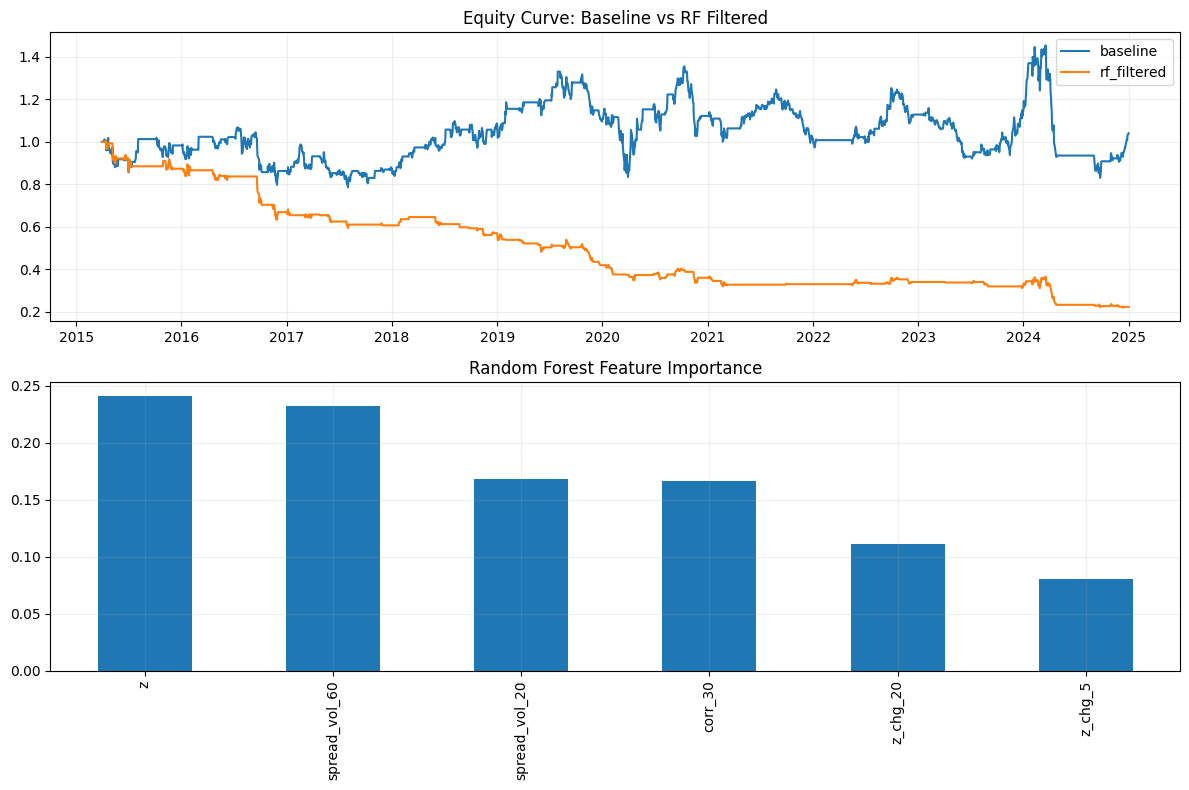

Saved: ../outputs/06_ml_equity_and_importance.png
Saved: ../data/ml_trade_series.csv


In [7]:
importances = pd.Series(rf.feature_importances_, index=X_cols).sort_values(ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
axes[0].plot(model_df.index, model_df['equity_base'], label='baseline')
axes[0].plot(model_df.index, model_df['equity_ml'], label='rf_filtered')
axes[0].set_title('Equity Curve: Baseline vs RF Filtered')
axes[0].legend()
axes[0].grid(alpha=0.2)

importances.plot(kind='bar', ax=axes[1])
axes[1].set_title('Random Forest Feature Importance')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(OUT_DIR / '06_ml_equity_and_importance.png', dpi=140, bbox_inches='tight')
plt.show()

model_df.to_csv(DATA_DIR / 'ml_trade_series.csv')
print('Saved: ../outputs/06_ml_equity_and_importance.png')
print('Saved: ../data/ml_trade_series.csv')